In [12]:

%pip install seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [13]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("enrique4/activity-recognition-with-accelerometer-and-sound")

print("Path to dataset files:", path)

data = pd.read_csv(path + '/features.csv')

data.head()

Path to dataset files: /Users/talasu/.cache/kagglehub/datasets/enrique4/activity-recognition-with-accelerometer-and-sound/versions/1


,userid,label,v1_mfcc1,v1_mfcc2,v1_mfcc3,v1_mfcc4,v1_mfcc5,v1_mfcc6,v1_mfcc7,v1_mfcc8,...,v2_maxX,v2_maxY,v2_maxZ,v2_corXY,v2_corXZ,v2_corYZ,v2_meanMagnitude,v2_sdMagnitude,v2_auc,v2_meanDif
0,user1,watch_tv,120.078886,3.025171,0.390508,-1.777848,-9.216060,-6.567632,-9.918761,-9.145534,...,0.097412,1.088135,0.227051,0.900163,-0.729511,-0.863478,1.014805,0.060424,70.021543,-0.000364
1,user1,watch_tv,130.243139,2.552278,-6.457879,-7.440159,-3.070106,-3.475476,-5.718819,-2.878174,...,0.703613,1.424805,0.818115,-0.210431,0.319599,-0.722541,1.005713,0.162644,79.451303,-0.006234
2,user1,watch_tv,122.259209,1.970267,-8.980575,-10.222030,-3.564994,-2.496906,-5.584900,-6.730588,...,0.312500,0.972656,-0.070312,-0.018862,-0.093852,-0.305722,1.002809,0.006100,77.216317,0.000019
3,user1,watch_tv,122.609566,3.188740,-7.049397,-10.569875,-0.220824,-0.649459,-4.975825,-6.856288,...,0.349854,1.020020,-0.053223,0.492439,0.273064,-0.023051,1.002878,0.021292,75.215866,-0.000023
4,user1,watch_tv,121.393023,1.338798,-8.706183,-8.654997,-4.935310,-3.401656,-5.031361,-7.957924,...,0.322266,0.955078,-0.076904,-0.226296,-0.217439,-0.053895,1.003427,0.002849,71.243346,-0.000083


__1. Dataset Exploration__

In [14]:
user_row_count = data.groupby('userid').count()
print(user_row_count['label'])
print('Total Users: ', len(user_row_count))
print('Total Records ', len(data))

userid
user1    466
user2    466
user3    454
Name: label, dtype: int64
Total Users:  3
Total Records  1386


The home-tasks data were collected by 3 individuals. They were 1 female and
2 males with ages ranging from 25 to 30. The subjects were asked to perform
7 home-task activities including: mop floor, sweep floor, type on computer keyboard, brush teeth, wash hands, eat chips and watch TV. The eat chips activity
was conducted with a bag of chips. Each individual performed each activity for
approximately 3 minutes. If the activity lasted less than 3 minutes, an additional
trial was conducted until the 3 minutes were completed. The volunteers used a
wrist-band (Microsoft Band 2) and a smartphone (Sony XPERIA) to collect the
data.

In [15]:
summary_table = {
    'Users': [len(user_row_count)],
    'Days per participant (21 minutes each, 3 minutes per each activity, 7 activities)':[0.01458333333],
    'Demographic Diversity (Age and Gender)': ['2 males and 1 female, ages: 25-30'],
    'Total Labels': [f'{len(data)}, {len(data)/len(user_row_count)} per user']
}
summary_table = pd.DataFrame(summary_table)
summary_table

,Users,"Days per participant (21 minutes each, 3 minutes per each activity, 7 activities)",Demographic Diversity (Age and Gender),Total Labels
0,3,0.014583,"2 males and 1 female, ages: 25-30","1386, 462.0 per user"


In [16]:
pd.set_option('display.max_rows', None)
act_by_subject = data.groupby(['userid', 'label']).count()
act_by_subject['v2_meanDif']

userid  label           
user1   brush_teeth          59
        eat_chips           153
        mop_floor            56
        sweep                47
        type_on_keyboard     49
        wash_hands           36
        watch_tv             66
user2   brush_teeth          57
        eat_chips            65
        mop_floor            63
        sweep                68
        type_on_keyboard     63
        wash_hands           79
        watch_tv             71
user3   brush_teeth          64
        eat_chips            64
        mop_floor            62
        sweep                63
        type_on_keyboard     67
        wash_hands           65
        watch_tv             69
Name: v2_meanDif, dtype: int64

__2. Annotated Signal Exploration__

Does the data have missing values?  False


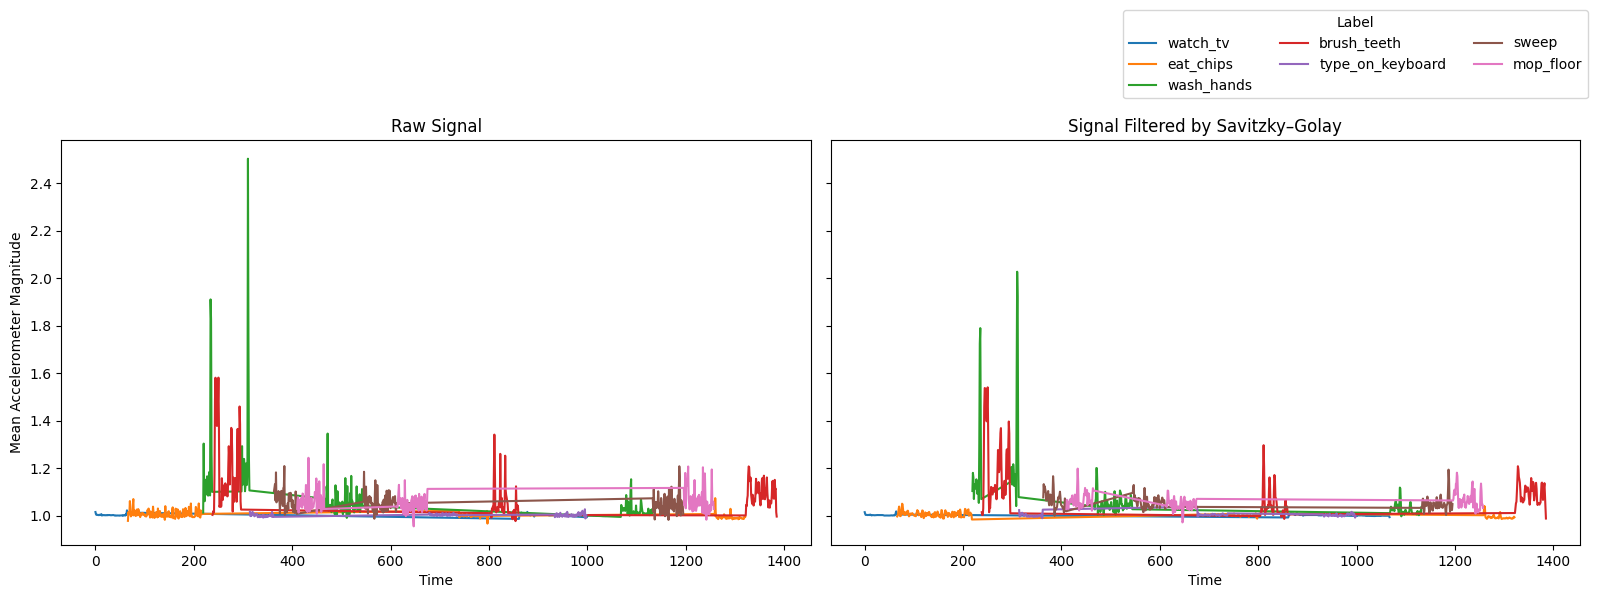

In [17]:
from scipy.signal import savgol_filter

has_missing_values = data.isna().any().any()
print('Does the data have missing values? ', has_missing_values)

filt = savgol_filter(data['v2_meanMagnitude'], window_length=5, polyorder=2)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
sns.lineplot(data=data, x=data.index, y='v2_meanMagnitude', hue='label', ax=axes[0]).set_title('Raw Signal')
sns.lineplot(data=data, x=data.index, y=filt, hue='label', ax=axes[1]).set_title('Signal Filtered by Savitzky–Golay')

axes[0].set_ylabel('Mean Accelerometer Magnitude')
axes[0].set_xlabel('Time')

axes[1].set_ylabel('Filtered Mean Accelerometer Magnitude')
axes[1].set_xlabel('Time')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1, 1.2), loc='upper right', ncol=3, title='Label')
axes[0].get_legend().remove()
axes[1].get_legend().remove()

plt.tight_layout()

__Narrative Explaining Raw Signal Patterns__  
Lorem Ipsum Dolor TO BE DONE

__3. Signal Preprocessing__

The raw accelerometer signals were preprocessed (uniform resampling to 30 Hz, median filter for sensor spike removal, then per-axis low-pass extraction of gravity, gravity subtraction, and a Butterworth band-pass on the remainder) so the body-acceleration plots reflect motion rather than wrist orientation. Time-domain plots showed clear differences among activities. Watch TV was mostly stable with small fluctuations, indicating low movement. Eat chips showed frequent repeated fluctuations, suggesting moderate periodic hand motion. Wash hands exhibited the largest and most irregular variations, indicating vigorous movement. Other activities such as brush teeth, sweep, and mop floor also showed larger variations than passive tasks. These visual differences suggest that feature extraction over body acceleration should be able to separate low-motion from high-motion activities.

In [18]:
from pathlib import Path
from collections import Counter

users = ["user1", "user2", "user3"]

files_by_user = {}

for user in users:
    data_dir = Path(path) / user
    items = []
    for fp in sorted(data_dir.glob("*-acc-*.txt")):
        activity = fp.stem.split("-acc-")[-1]
        items.append((activity, fp.stem, str(fp)))
    files_by_user[user] = items

print("Files per user:", {u: len(v) for u, v in files_by_user.items()})
for user, items in files_by_user.items():
    counts = Counter(act for act, src, fp in items)
    print(f"  {user}: {dict(counts)}")

Files per user: {'user1': 8, 'user2': 9, 'user3': 7}
  user1: {'watch_tv': 1, 'eat_chips': 1, 'wash_hands': 2, 'brush_teeth': 1, 'type_on_keyboard': 1, 'sweep': 1, 'mop_floor': 1}
  user2: {'wash_hands': 3, 'sweep': 1, 'mop_floor': 1, 'type_on_keyboard': 1, 'eat_chips': 1, 'brush_teeth': 1, 'watch_tv': 1}
  user3: {'type_on_keyboard': 1, 'watch_tv': 1, 'wash_hands': 1, 'sweep': 1, 'mop_floor': 1, 'eat_chips': 1, 'brush_teeth': 1}


raw_data activities: ['watch_tv', 'eat_chips', 'wash_hands', 'brush_teeth', 'type_on_keyboard', 'sweep', 'mop_floor']
raw_data sample counts: {'watch_tv': 19027, 'eat_chips': 25357, 'wash_hands': 16227, 'brush_teeth': 16195, 'type_on_keyboard': 16171, 'sweep': 16077, 'mop_floor': 16279}


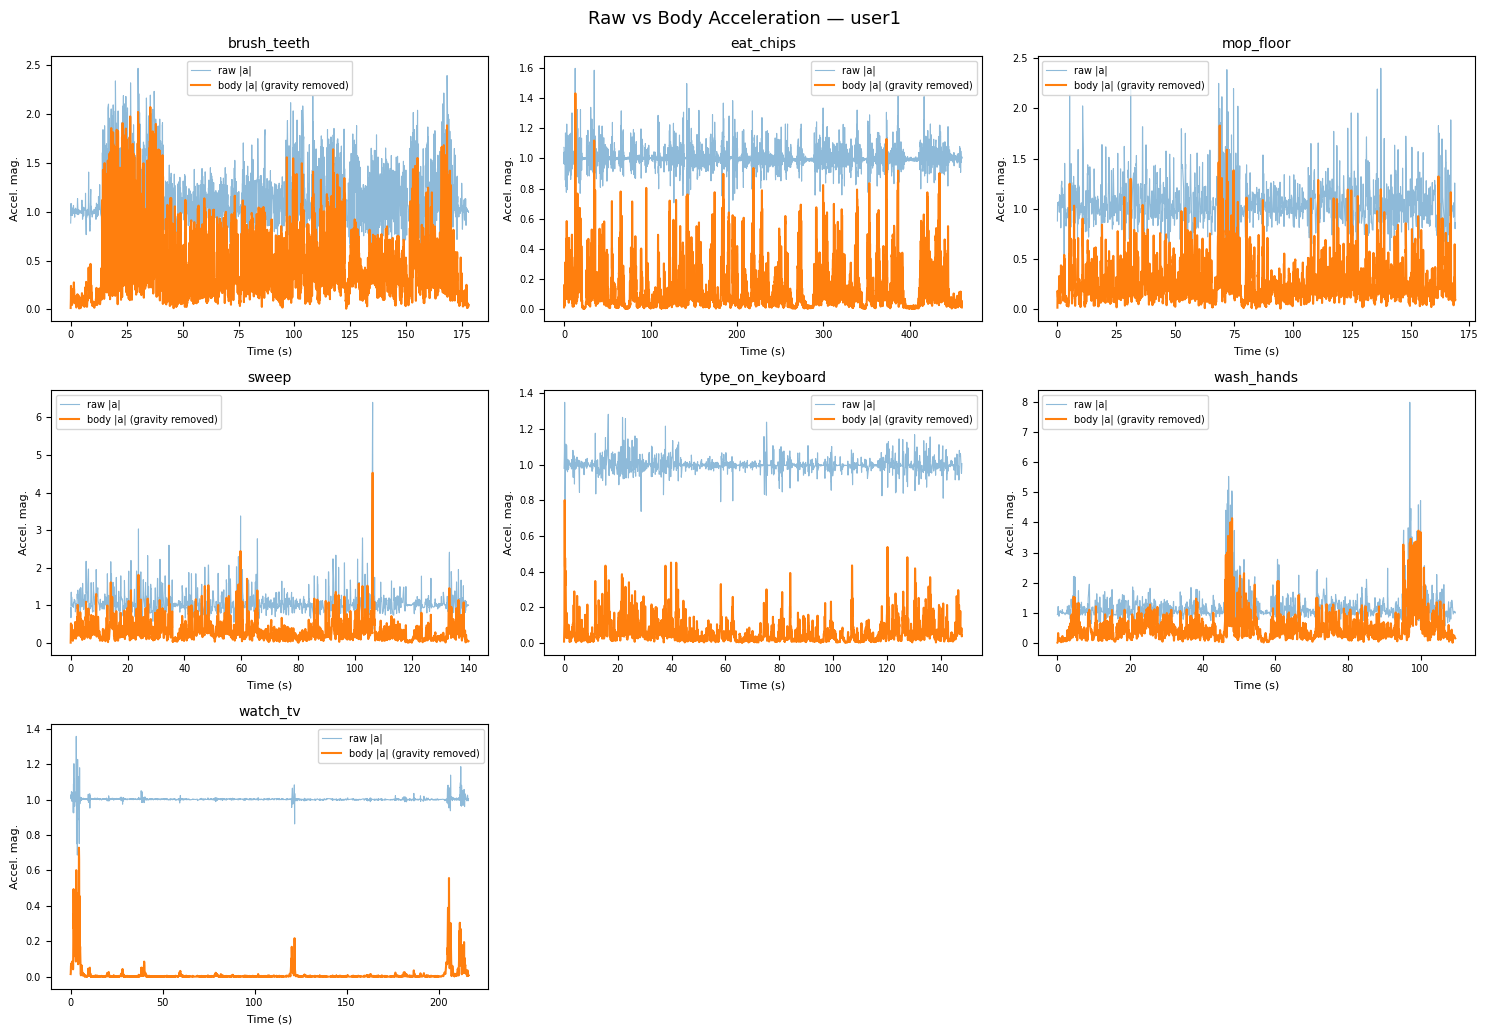

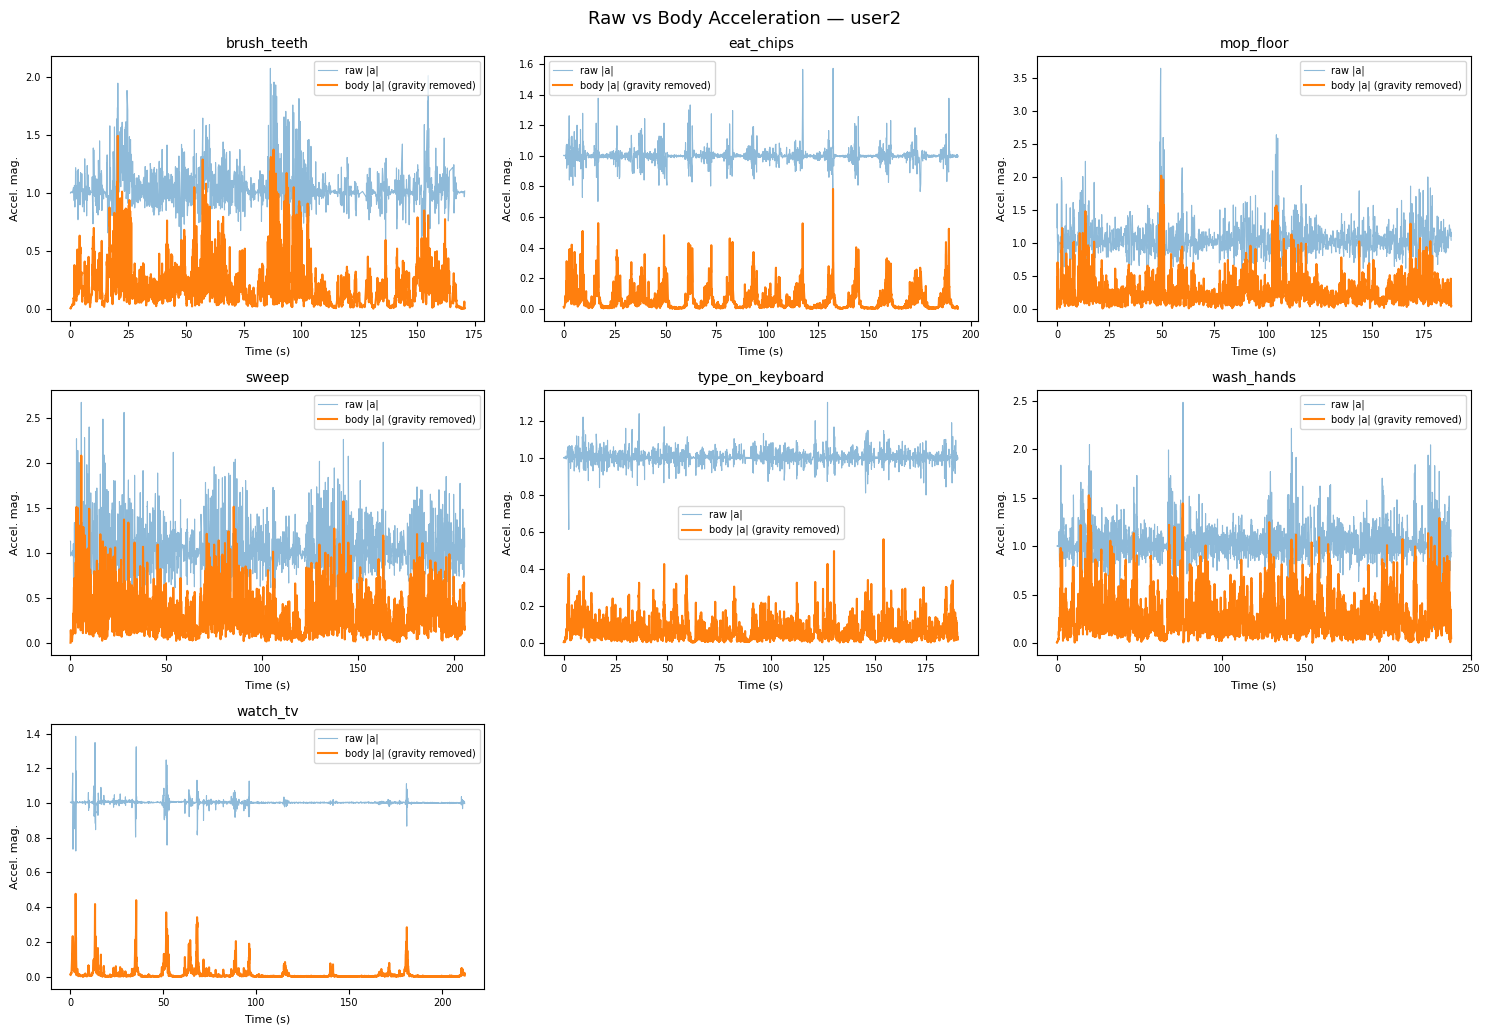

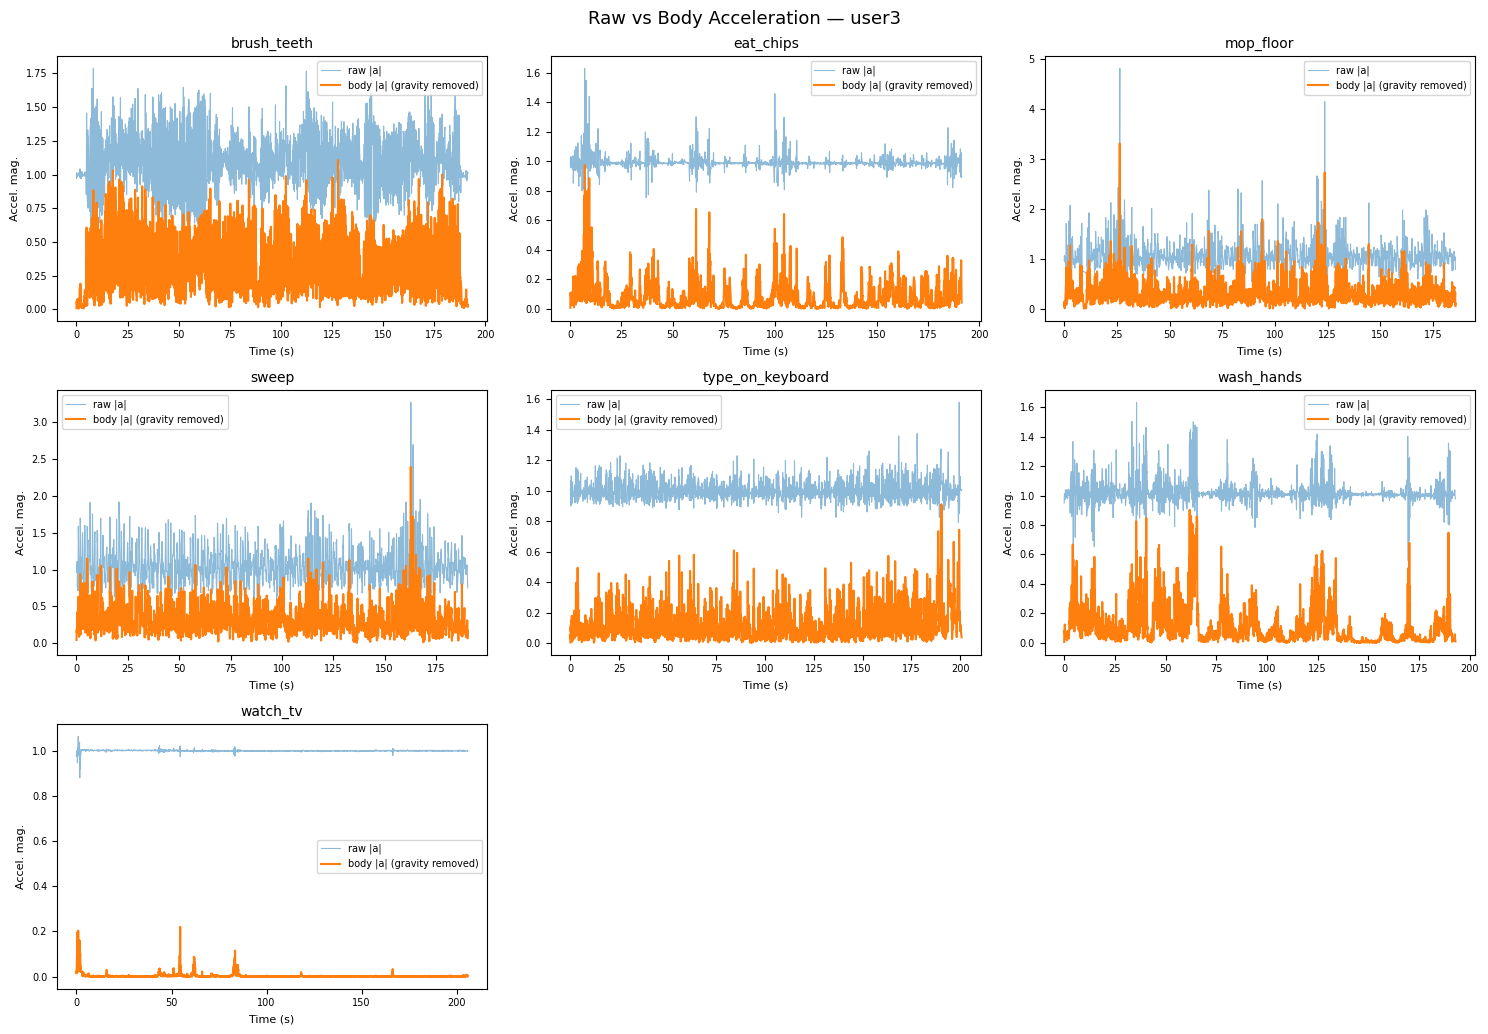

In [19]:
import math
from scipy.signal import butter, filtfilt, medfilt

def estimate_sampling_rate(df):
    dt = np.diff(df["time_sec"])
    dt = dt[dt > 0]
    fs = 1 / np.mean(dt)
    return fs

def gravity_body_split(sig, fs, gravity_cutoff_hz=0.5, body_band=(0.25, 12.0), order=4):
    """Estimate the gravity component (low-pass), subtract it, then band-pass the remainder."""
    sig = np.asarray(sig, dtype=float)
    nyq = 0.5 * fs
    if sig.size < 30 or nyq <= 0:
        return sig.copy(), np.zeros_like(sig)

    cutoff = min(gravity_cutoff_hz, nyq * 0.99) / nyq
    b_g, a_g = butter(order, cutoff, btype="low")
    gravity = filtfilt(b_g, a_g, sig)

    body = sig - gravity
    low, high = body_band
    if high < nyq and low > 0 and low < high:
        b_b, a_b = butter(order, [low / nyq, high / nyq], btype="band")
        body = filtfilt(b_b, a_b, body)
    return gravity, body

def resample_uniform(df, target_fs=30.0):
    """Resample irregularly-sampled accel data to a uniform target_fs (Hz)."""
    t = df["time_sec"].to_numpy(dtype=float)
    if t.size < 3 or (t[-1] - t[0]) < 1.0:
        return df.copy()

    step = 1.0 / target_fs
    t_new = np.arange(t[0], t[-1] + step, step)
    out = pd.DataFrame({"time_sec": t_new})
    for col in ("x", "y", "z", "magnitude"):
        out[col] = np.interp(t_new, t, df[col].to_numpy(dtype=float))
    return out

def preprocess_signal(df):
    df = df.copy()
    df = df.sort_values("time_sec").reset_index(drop=True)

    for col in ["x", "y", "z", "magnitude"]:
        if df[col].isna().sum() > 0:
            df[col] = df[col].interpolate(method="linear").bfill().ffill()

    df = resample_uniform(df, target_fs=30.0)

    for col in ("x", "y", "z", "magnitude"):
        df[col] = medfilt(df[col].to_numpy(dtype=float), kernel_size=3)

    fs = estimate_sampling_rate(df)

    win = int(fs * 0.5)
    if win % 2 == 0:
        win += 1
    win = max(5, win)
    if win >= len(df):
        win = len(df) - 1 if len(df) % 2 == 0 else len(df)

    df["x_smooth"] = savgol_filter(df["x"], window_length=win, polyorder=2)
    df["y_smooth"] = savgol_filter(df["y"], window_length=win, polyorder=2)
    df["z_smooth"] = savgol_filter(df["z"], window_length=win, polyorder=2)
    df["mag_smooth"] = savgol_filter(df["magnitude"], window_length=win, polyorder=2)

    for axis in ("x", "y", "z"):
        g, body = gravity_body_split(df[axis].values, fs)
        df[f"{axis}_g"] = g
        df[f"{axis}_b"] = body
    df["mag_g"] = np.sqrt(df["x_g"]**2 + df["y_g"]**2 + df["z_g"]**2)
    df["mag_b"] = np.sqrt(df["x_b"]**2 + df["y_b"]**2 + df["z_b"]**2)

    for axis in ("x_b", "y_b", "z_b"):
        df[f"jerk_{axis}"] = np.gradient(df[axis].values) * fs
    df["jerk_mag_b"] = np.sqrt(df["jerk_x_b"]**2 + df["jerk_y_b"]**2 + df["jerk_z_b"]**2)

    return df

def load_acc_file(filepath):
    df = pd.read_csv(filepath, header=None, names=["timestamp", "x", "y", "z"])
    df["time_sec"] = (df["timestamp"] - df["timestamp"].iloc[0]) / 1000.0
    df["magnitude"] = np.sqrt(df["x"]**2 + df["y"]**2 + df["z"]**2)
    return df

def concat_sessions(dfs):
    if len(dfs) == 1:
        return dfs[0]
    offset = 0.0
    out = []
    for df in dfs:
        d = df.copy()
        d["time_sec"] = d["time_sec"] + offset
        out.append(d)
        offset = d["time_sec"].iloc[-1] + 1.0 / 30.0   # one-sample gap at the join
    return pd.concat(out, ignore_index=True)

user_raw_data = {}
for user, items in files_by_user.items():
    by_activity = {}
    for activity, source, fp in items:
        proc = preprocess_signal(load_acc_file(fp))
        proc["userid"] = user
        proc["source"] = source
        by_activity.setdefault(activity, []).append(proc)
    user_raw_data[user] = {act: concat_sessions(dfs) for act, dfs in by_activity.items()}

from collections import defaultdict
_dfs_by_activity = defaultdict(list)
for _u in users:
    for _activity, _df in user_raw_data[_u].items():
        _dfs_by_activity[_activity].append(_df)
raw_data = {act: concat_sessions(dfs) for act, dfs in _dfs_by_activity.items()}

print(f"raw_data activities: {list(raw_data.keys())}")
print("raw_data sample counts:", {a: len(df) for a, df in raw_data.items()})

for user in users:
    labels = sorted(user_raw_data[user].keys())
    n = len(labels)
    cols = 3
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3.5 * rows))
    axes = axes.flatten()

    for idx, label in enumerate(labels):
        ax = axes[idx]
        df = user_raw_data[user][label]
        ax.plot(df["time_sec"], df["magnitude"], label="raw |a|", alpha=0.5, linewidth=0.8)
        ax.plot(df["time_sec"], df["mag_b"], label="body |a| (gravity removed)", linewidth=1.5)
        ax.set_title(label, fontsize=10)
        ax.set_xlabel("Time (s)", fontsize=8)
        ax.set_ylabel("Accel. mag.", fontsize=8)
        ax.tick_params(labelsize=7)
        ax.legend(fontsize=7)

    for idx in range(n, len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle(f"Raw vs Body Acceleration — {user}", fontsize=13)
    plt.tight_layout()
    plt.show()

The plots compare two views of the same recordings: the raw magnitude (after resampling and median filtering, but with gravity still present) sits around the ~1 g baseline and varies subtly with motion; the body magnitude (gravity removed via low-pass extraction and subtraction, then band-passed at 0.25–12 Hz) sits near zero at rest and produces clear bursts during movement. Two findings are visible. First, activities are distinguishable on body magnitude: low-motion actions (such as watch TV) remain nearly flat near zero, while more active tasks (such as wash hands, sweep, and mop floor) show large bursts that are far less obvious on the raw line because the gravity baseline dominates any visual contrast. Second, the same activity exhibits user-specific differences in amplitude and timing, indicating inter-user variability. 

__4. Windowing Strategies__

In [20]:
window_sizes = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]

def normalized_energy(x):
    x = np.asarray(x)
    return np.mean(x**2)

# Compute CV-energy per user separately so window-size selection can be
# inspected and justified per subject.
energy_results = {}

for user in users:
    raw_u = user_raw_data[user]
    results = []
    for label, df in raw_u.items():
        fs = estimate_sampling_rate(df)
        signal = df["mag_b"].values   # body acceleration magnitude (gravity removed)
        n_samples = len(signal)

        for w in window_sizes:
            window_size = int(w * fs)
            step_size = int(window_size * 0.5)   # 50% overlap

            window_energies = []
            if window_size > 1 and step_size > 0 and n_samples >= window_size:
                for start in range(0, n_samples - window_size + 1, step_size):
                    window = signal[start:start + window_size]
                    window_energies.append(normalized_energy(window))

            if len(window_energies) > 0:
                mean_e = np.mean(window_energies)
                std_e = np.std(window_energies)
                cv_e = std_e / mean_e if mean_e != 0 else np.nan
            else:
                mean_e = std_e = cv_e = np.nan

            results.append({
                "activity":       label,
                "window_sec":     w,
                "window_samples": window_size,
                "num_windows":    len(window_energies),
                "cv_energy":      cv_e,
            })

    energy_results[user] = pd.DataFrame(results)

print("Per-user CV-energy results computed for:", list(energy_results.keys()))

Per-user CV-energy results computed for: ['user1', 'user2', 'user3']


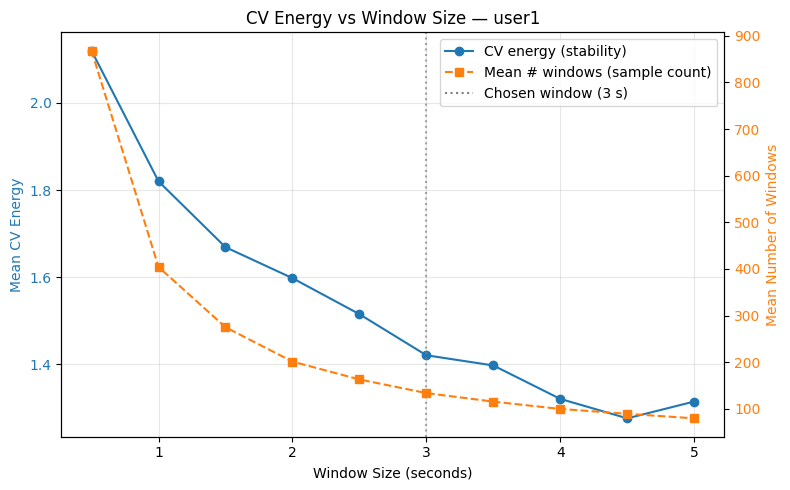

,window_sec,cv_energy,num_windows
0,0.5,2.1197,868.1429
1,1.0,1.8200,404.4286
2,1.5,1.6689,275.1429
3,2.0,1.5978,201.4286
4,2.5,1.5152,163.1429
5,3.0,1.4208,133.8571
6,3.5,1.3974,115.5714
7,4.0,1.3207,99.8571
8,4.5,1.2761,89.4286
9,5.0,1.3147,79.7143


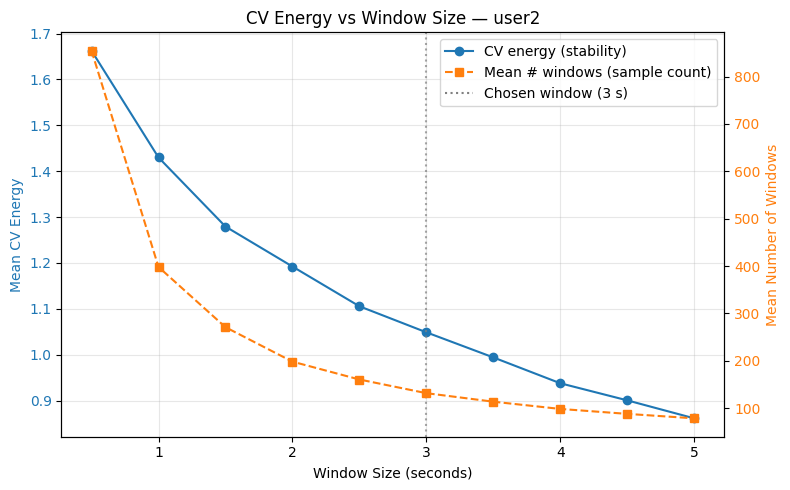

,window_sec,cv_energy,num_windows
0,0.5,1.6626,854.7143
1,1.0,1.4299,398.1429
2,1.5,1.2793,271.0000
3,2.0,1.1922,198.2857
4,2.5,1.1055,160.5714
5,3.0,1.0487,131.7143
6,3.5,0.9940,113.7143
7,4.0,0.9377,98.4286
8,4.5,0.9004,88.0000
9,5.0,0.8612,78.5714


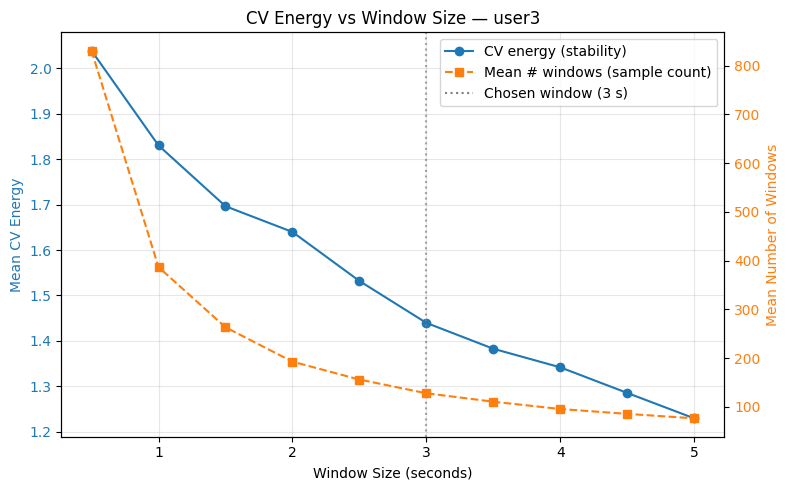

,window_sec,cv_energy,num_windows
0,0.5,2.0386,830.4286
1,1.0,1.8302,386.5714
2,1.5,1.6965,263.1429
3,2.0,1.6398,192.5714
4,2.5,1.5320,155.8571
5,3.0,1.4397,127.7143
6,3.5,1.3828,110.4286
7,4.0,1.3419,95.4286
8,4.5,1.2856,85.4286
9,5.0,1.2297,76.2857


In [21]:
for user in users:
    summary_plot = (
        energy_results[user]
        .groupby("window_sec")[["cv_energy", "num_windows"]]
        .mean()
        .reset_index()
    )

    fig, ax1 = plt.subplots(figsize=(8, 5))

    # Left axis: CV energy
    line_cv, = ax1.plot(
        summary_plot["window_sec"], summary_plot["cv_energy"],
        marker="o", color="tab:blue", label="CV energy (stability)",
    )
    ax1.set_xlabel("Window Size (seconds)")
    ax1.set_ylabel("Mean CV Energy", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax1.grid(True, alpha=0.3)
    ax1.axvline(x=3.0, color="gray", linestyle=":", alpha=0.7, label="Chosen window (3 s)")

    # Right axis: number of windows
    ax2 = ax1.twinx()
    line_nw, = ax2.plot(
        summary_plot["window_sec"], summary_plot["num_windows"],
        marker="s", linestyle="--", color="tab:orange",
        label="Mean # windows (sample count)",
    )
    ax2.set_ylabel("Mean Number of Windows", color="tab:orange")
    ax2.tick_params(axis="y", labelcolor="tab:orange")

    # Unified legend combining both axes
    handles = [line_cv, line_nw, plt.Line2D([0], [0], color="gray", linestyle=":", label="Chosen window (3 s)")]
    ax1.legend(handles=handles, loc="upper right")

    plt.title(f"CV Energy vs Window Size — {user}")
    plt.tight_layout()
    plt.show()

    display(summary_plot.round(4))

Different window sizes from 0.5 to 5.0 seconds were evaluated using 50% overlap. For each window, normalized energy was computed, and stability was measured using the coefficient of variation (CV), defined as standard deviation divided by mean energy. Lower CV indicates more consistent energy across windows (more stable segmentation), while higher CV indicates greater variability in motion patterns.

Across activities and users, CV generally decreases as window size increases, indicating that larger windows produce more stable energy estimates. However, larger windows also reduce the number of available segments and can lower temporal sensitivity to short behavior changes. A 3-second window provides a practical balance: it substantially improves stability while preserving enough windows for reliable analysis and downstream modeling.

__5. Feature Extraction and Analysis__

In [22]:
from scipy.stats import entropy
WINDOW_SEC = 3.0
OVERLAP = 0.5   # 50% overlap

CHANNELS = [
    "x_b", "y_b", "z_b", "mag_b",
]

def zero_crossing_rate(x):
    x = np.asarray(x)
    x_centered = x - np.mean(x)
    signs = np.sign(x_centered)
    signs[signs == 0] = 1
    return np.mean(signs[:-1] != signs[1:])

def spectral_entropy_from_power(power):
    power = np.asarray(power, dtype=float)
    power = power[power > 0]
    if len(power) == 0:
        return 0.0
    p = power / power.sum()
    return entropy(p, base=2)

def extract_window_features(signal, fs):
    signal = np.asarray(signal, dtype=float)

    #time domain features
    mean_val = np.mean(signal)
    sd_val = np.std(signal)
    rms_val = np.sqrt(np.mean(signal**2))
    zcr_val = zero_crossing_rate(signal)

    #frequency domain features
    detrended = signal - np.mean(signal)
    spectrum = np.fft.rfft(detrended)
    freqs = np.fft.rfftfreq(len(detrended), d=1/fs)
    power = np.abs(spectrum)**2

    if len(power) > 1:
        dominant_freq = freqs[1:][np.argmax(power[1:])]
    else:
        dominant_freq = 0.0

    spectral_energy = np.sum(power) / len(power)
    spectral_entropy = spectral_entropy_from_power(power)

    return {
        "mean": mean_val,
        "sd": sd_val,
        "rms": rms_val,
        "zcr": zcr_val,
        "dominant_freq": dominant_freq,
        "spectral_energy": spectral_energy,
        "spectral_entropy": spectral_entropy
    }

def _safe_corr(a, b):
    if np.std(a) < 1e-10 or np.std(b) < 1e-10:
        return 0.0
    c = np.corrcoef(a, b)[0, 1]
    return 0.0 if np.isnan(c) or np.isinf(c) else float(c)

def build_feature_table(raw_data, window_sec=3.0, overlap=0.5):
    feature_rows = []

    for activity, df in raw_data.items():
        fs = estimate_sampling_rate(df)
        n_samples = len(df)

        window_size = int(window_sec * fs)
        step_size = max(1, int(window_size * (1 - overlap)))

        if n_samples < window_size:
            continue

        for start in range(0, n_samples - window_size + 1, step_size):
            feats = {}

            for ch in CHANNELS:
                window = df[ch].values[start:start + window_size]
                ch_feats = extract_window_features(window, fs)
                for k, v in ch_feats.items():
                    feats[f"{ch}_{k}"] = v

            x_w = df["x_b"].values[start:start + window_size]
            y_w = df["y_b"].values[start:start + window_size]
            z_w = df["z_b"].values[start:start + window_size]
            feats["corr_xy_b"] = _safe_corr(x_w, y_w)
            feats["corr_xz_b"] = _safe_corr(x_w, z_w)
            feats["corr_yz_b"] = _safe_corr(y_w, z_w)

            for k, v in list(feats.items()):
                if isinstance(v, float) and (np.isnan(v) or np.isinf(v)):
                    feats[k] = 0.0

            feats["activity"] = activity
            if "userid" in df.columns:
                feats["userid"] = df["userid"].iloc[start:start + window_size].mode().iloc[0]
            if "source" in df.columns:
                feats["source"] = df["source"].iloc[start:start + window_size].mode().iloc[0]
            feature_rows.append(feats)

    return pd.DataFrame(feature_rows)

feature_df = build_feature_table(raw_data, window_sec=WINDOW_SEC, overlap=OVERLAP)

n_features = sum(1 for c in feature_df.columns if c not in ("activity", "userid", "source"))
print(f"Feature table shape: {feature_df.shape}  ({n_features} features)")
display(feature_df.head())

Feature table shape: (2774, 34)  (31 features)


,x_b_mean,x_b_sd,x_b_rms,x_b_zcr,x_b_dominant_freq,x_b_spectral_energy,x_b_spectral_entropy,y_b_mean,y_b_sd,y_b_rms,...,mag_b_zcr,mag_b_dominant_freq,mag_b_spectral_energy,mag_b_spectral_entropy,corr_xy_b,corr_xz_b,corr_yz_b,activity,userid,source
0,-0.021387,0.123359,0.125199,0.078652,0.333333,1.339919,3.242590,-0.016329,0.114665,0.115822,...,0.078652,0.333333,1.060932,2.999998,0.423589,-0.173423,-0.722405,watch_tv,user1,1468360517106-acc-watch_tv
1,0.004003,0.178287,0.178332,0.101124,1.000000,2.798913,3.289568,0.015701,0.184844,0.185510,...,0.112360,1.333333,1.395067,3.633624,-0.051548,0.008224,-0.667845,watch_tv,user1,1468360517106-acc-watch_tv
2,0.015116,0.137382,0.138211,0.157303,1.000000,1.661841,3.429192,0.015030,0.215868,0.216391,...,0.101124,0.666667,2.903598,3.373808,-0.246354,0.084793,-0.806472,watch_tv,user1,1468360517106-acc-watch_tv
3,0.002859,0.013555,0.013853,0.067416,0.333333,0.016186,4.096395,-0.007803,0.158441,0.158633,...,0.033708,0.333333,2.543433,3.390353,0.022175,0.009067,-0.938294,watch_tv,user1,1468360517106-acc-watch_tv
4,-0.001193,0.002945,0.003177,0.033708,0.333333,0.000764,2.388053,-0.001592,0.008804,0.008947,...,0.033708,0.333333,0.012464,3.231520,0.445440,-0.431518,-0.973300,watch_tv,user1,1468360517106-acc-watch_tv


In [23]:
feature_cols = [c for c in feature_df.columns if c not in ("activity", "userid", "source")]
print(f"Using {len(feature_cols)} feature columns.")

summary_by_activity = feature_df.groupby("activity")[feature_cols].mean().round(4)
display(summary_by_activity)

Using 31 feature columns.


,x_b_mean,x_b_sd,x_b_rms,x_b_zcr,x_b_dominant_freq,x_b_spectral_energy,x_b_spectral_entropy,y_b_mean,y_b_sd,y_b_rms,...,mag_b_mean,mag_b_sd,mag_b_rms,mag_b_zcr,mag_b_dominant_freq,mag_b_spectral_energy,mag_b_spectral_entropy,corr_xy_b,corr_xz_b,corr_yz_b
activity,,,,,,,,,,,,,,,,,,,,,
brush_teeth,-0.0000,0.2078,0.2081,0.1973,3.1862,6.0163,3.1548,-0.0000,0.2033,0.2036,...,0.3637,0.1890,0.4116,0.3112,4.0689,4.0097,3.8964,0.2799,-0.4384,-0.3358
eat_chips,0.0000,0.0443,0.0445,0.1229,1.1797,0.2900,3.1755,0.0000,0.0957,0.0961,...,0.1059,0.0741,0.1303,0.1316,0.6394,0.7081,3.3500,-0.2120,-0.2929,-0.2076
mop_floor,-0.0000,0.2131,0.2140,0.0969,1.0269,4.7576,2.7369,-0.0002,0.2070,0.2076,...,0.3122,0.1772,0.3607,0.1530,0.9824,3.2437,3.5183,-0.2475,-0.2249,0.1209
sweep,0.0002,0.2360,0.2367,0.1021,1.0955,5.3900,2.7131,-0.0002,0.2281,0.2285,...,0.3408,0.1880,0.3910,0.1628,1.0787,3.6668,3.6076,-0.4835,-0.3420,0.1742
type_on_keyboard,-0.0000,0.0682,0.0683,0.1526,1.7561,0.5510,3.4702,0.0000,0.0610,0.0611,...,0.0891,0.0634,0.1100,0.1668,0.7561,0.4299,3.6051,0.0504,-0.3842,-0.2755
wash_hands,0.0005,0.1396,0.1399,0.1558,1.8793,3.2313,3.5042,-0.0000,0.1688,0.1691,...,0.2776,0.1697,0.3274,0.1764,0.8858,4.3016,3.6290,-0.0577,-0.0502,-0.0242
watch_tv,-0.0000,0.0069,0.0070,0.1764,1.8021,0.0319,3.7816,-0.0000,0.0094,0.0094,...,0.0115,0.0103,0.0156,0.1892,0.8678,0.0555,3.7958,0.0472,-0.1286,-0.2377


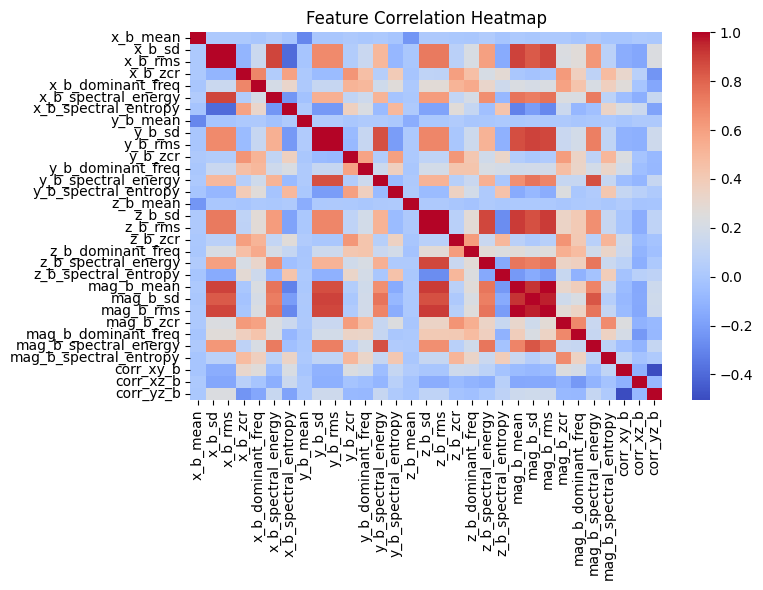

In [24]:
# Correlation analysis (heatmap)
corr_matrix = feature_df[feature_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

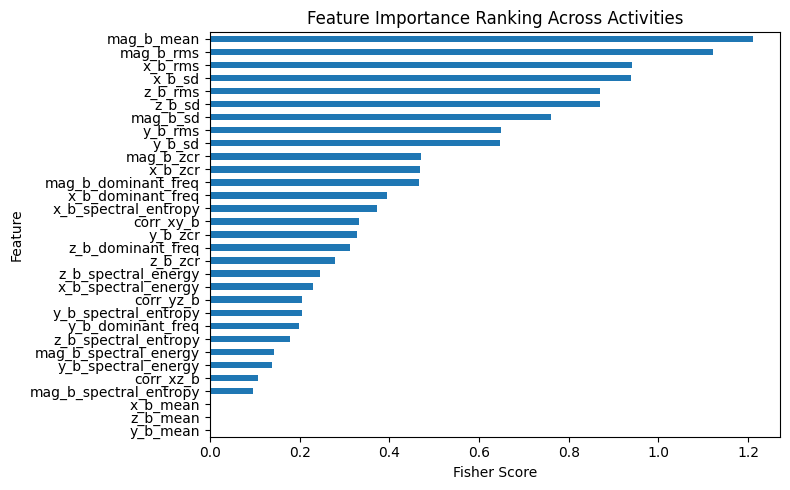

,fisher_score
mag_b_mean,1.210617
mag_b_rms,1.120679
x_b_rms,0.942202
x_b_sd,0.938924
z_b_rms,0.870720
z_b_sd,0.869233
mag_b_sd,0.759891
y_b_rms,0.648056
y_b_sd,0.646950
mag_b_zcr,0.469697


In [25]:
# Feature importance ranking
# Using multiclass Fisher Score
def fisher_score_multiclass(X, y):
    scores = {}
    overall_mean = X.mean()

    for col in X.columns:
        numerator = 0.0
        denominator = 0.0

        for cls in sorted(y.unique()):
            x_c = X.loc[y == cls, col]
            n_c = len(x_c)
            mu_c = x_c.mean()
            var_c = x_c.var(ddof=0)

            numerator += n_c * (mu_c - overall_mean[col])**2
            denominator += n_c * var_c

        scores[col] = numerator / denominator if denominator != 0 else 0.0

    return pd.Series(scores).sort_values(ascending=False)

fisher_scores = fisher_score_multiclass(feature_df[feature_cols], feature_df["activity"])

plt.figure(figsize=(8, 5))
fisher_scores.sort_values().plot(kind="barh")
plt.xlabel("Fisher Score")
plt.ylabel("Feature")
plt.title("Feature Importance Ranking Across Activities")
plt.tight_layout()
plt.show()

display(fisher_scores.rename("fisher_score").to_frame())

For feature extract, we extracted both time-domain and frequency-domain features from the smoothed accelerometer magnitude signal using 3-second windows with 50% overlap. The time-domain features were mean, standard deviation, root mean square (RMS), and zero-crossing rate (ZCR). These describe the overall intensity, variability, signal power, and amount of directional fluctuation in motion. The frequency-domain features were dominant frequency, spectral energy, and spectral entropy, which capture periodicity, strength of oscillation, and complexity of motion patterns.

The correlation heatmap helps show which features provide similar information. In general, RMS and spectral energy are often strongly related because both reflect signal strength, while standard deviation also tends to increase for more vigorous activities. Features (like dominant frequency) and (spectral entropy) are useful because they capture different aspects of movement that are not fully explained by signal magnitude alone.

The feature-importance ranking shows which features are most helpful for separating activities. Higher-ranked features contribute more strongly to distinguishing passive activities such as watching TV from repetitive actions such as brushing teeth, sweeping, or mopping. In particular, variability based and energy based features are expected to be strong because active tasks produce larger and less stable motion signals, while frequency-based features help identify repeated movement patterns.
Overall, combining time-domain and frequency-domain features gives a more complete representation of human activity than using either type alone.

__6. Modeling__

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.

=== Decision Tree ===
Accuracy: 0.7171
Precision (macro): 0.7130
Recall (macro): 0.7143
F1 (macro): 0.7121
              precision    recall  f1-score   support

           0       0.72      0.72      0.72        72
           1       0.79      0.71      0.75       112
           2       0.58      0.67      0.62        72
           3       0.60      0.65      0.62        71
           4       0.74      0.79      0.77        72
           5       0.69      0.60      0.64        72
           6       0.87      0.87      0.87        84

    accuracy                           0.72       555
   macro avg       0.71      0.71      0.71       555
weighted avg       0.72      0.72      0.72       555



,0,1,2,3,4,5,6
0,52,5,8,1,1,4,1
1,4,79,2,4,14,3,6
2,1,1,48,18,0,4,0
3,1,0,19,46,0,5,0
4,3,3,2,3,57,2,2
5,10,6,4,5,2,43,2
6,1,6,0,0,3,1,73



=== SVM ===
Accuracy: 0.7730
Precision (macro): 0.7807
Recall (macro): 0.7712
F1 (macro): 0.7728
              precision    recall  f1-score   support

           0       0.89      0.76      0.82        72
           1       0.79      0.75      0.77       112
           2       0.64      0.75      0.69        72
           3       0.77      0.70      0.74        71
           4       0.86      0.78      0.82        72
           5       0.78      0.74      0.76        72
           6       0.75      0.92      0.82        84

    accuracy                           0.77       555
   macro avg       0.78      0.77      0.77       555
weighted avg       0.78      0.77      0.77       555



,0,1,2,3,4,5,6
0,55,3,3,2,2,6,1
1,1,84,2,1,5,1,18
2,0,3,54,10,0,5,0
3,0,0,19,50,1,1,0
4,2,9,0,1,56,2,2
5,1,5,7,1,0,53,5
6,3,3,0,0,1,0,77



=== Naive Bayes ===
Accuracy: 0.6360
Precision (macro): 0.6633
Recall (macro): 0.6409
F1 (macro): 0.6298
              precision    recall  f1-score   support

           0       0.90      0.72      0.80        72
           1       0.59      0.47      0.52       112
           2       0.52      0.64      0.57        72
           3       0.71      0.65      0.68        71
           4       0.64      0.72      0.68        72
           5       0.71      0.31      0.43        72
           6       0.58      0.98      0.73        84

    accuracy                           0.64       555
   macro avg       0.66      0.64      0.63       555
weighted avg       0.66      0.64      0.62       555



...


=== XGBoost ===
Accuracy: 0.8036
Precision (macro): 0.8016
Recall (macro): 0.7973
F1 (macro): 0.7983
              precision    recall  f1-score   support

           0       0.84      0.81      0.82        72
           1       0.81      0.85      0.83       112
           2       0.68      0.71      0.69        72
           3       0.74      0.76      0.75        71
           4       0.83      0.88      0.85        72
           5       0.80      0.67      0.73        72
           6       0.92      0.92      0.92        84

    accuracy                           0.80       555
   macro avg       0.80      0.80      0.80       555
weighted avg       0.80      0.80      0.80       555



,0,1,2,3,4,5,6
0,58,4,3,1,2,3,1
1,1,95,2,1,7,1,5
2,1,2,51,11,1,6,0
3,0,0,15,54,1,1,0
4,1,7,0,1,63,0,0
5,6,7,4,5,1,48,1
6,2,3,0,0,1,1,77



=== Model Summary ===


,Accuracy,Precision,Recall,F1
Model,,,,
XGBoost,0.803604,0.801572,0.797286,0.798279
Random Forest,0.785586,0.804072,0.775121,0.783688
SVM,0.772973,0.780742,0.771239,0.772772
Decision Tree,0.717117,0.712971,0.714296,0.712060
Naive Bayes,0.636036,0.663314,0.640883,0.629781
AdaBoost,0.533333,0.551902,0.534800,0.522394


<Figure size 800x500 with 0 Axes>

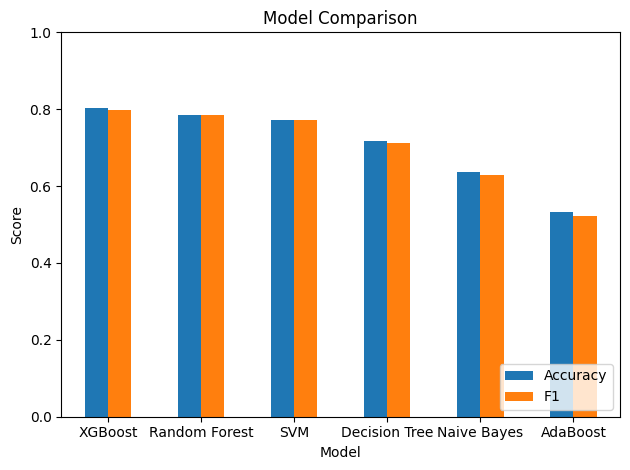

In [26]:

%pip install xgboost
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# Encode activity labels
le = LabelEncoder()
feature_df["activity"] = le.fit_transform(feature_df["activity"])


X = feature_df[feature_cols]
y = feature_df["activity"]

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Standardize features
scaler=StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

joblib.dump(scaler, "scaler.joblib")

# Define models with fixed random states for reproducibility
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "SVM": SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
    )
}


results = []

for name, model in models.items():
    print(f"\n=== {name} ===")

    sw = compute_sample_weight(class_weight='balanced', y=y_train)
    model.fit(X_train, y_train, sample_weight=sw)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision (macro): {precision:.4f}")
    print(f"Recall (macro): {recall:.4f}")
    print(f"F1 (macro): {f1:.4f}")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(cm, index=model.classes_, columns=model.classes_)
    display(cm_df)

    results.append(
        {
            "Model": name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
        }
    )

results_df = pd.DataFrame(results).set_index("Model").sort_values(by="Accuracy", ascending=False)

print("\n=== Model Summary ===")
display(results_df)

plt.figure(figsize=(8, 5))
results_df[["Accuracy", "F1"]].plot(kind="bar", ylim=(0, 1), rot=0)
plt.title("Model Comparison")
plt.ylabel("Score")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Deep learning input X_dl shape:  (2774, 90, 4)
Deep learning labels y_dl shape: (2774,)
Channels: ['x_b', 'y_b', 'z_b', 'mag_b']
Unique activities: [np.str_('brush_teeth'), np.str_('eat_chips'), np.str_('mop_floor'), np.str_('sweep'), np.str_('type_on_keyboard'), np.str_('wash_hands'), np.str_('watch_tv')]


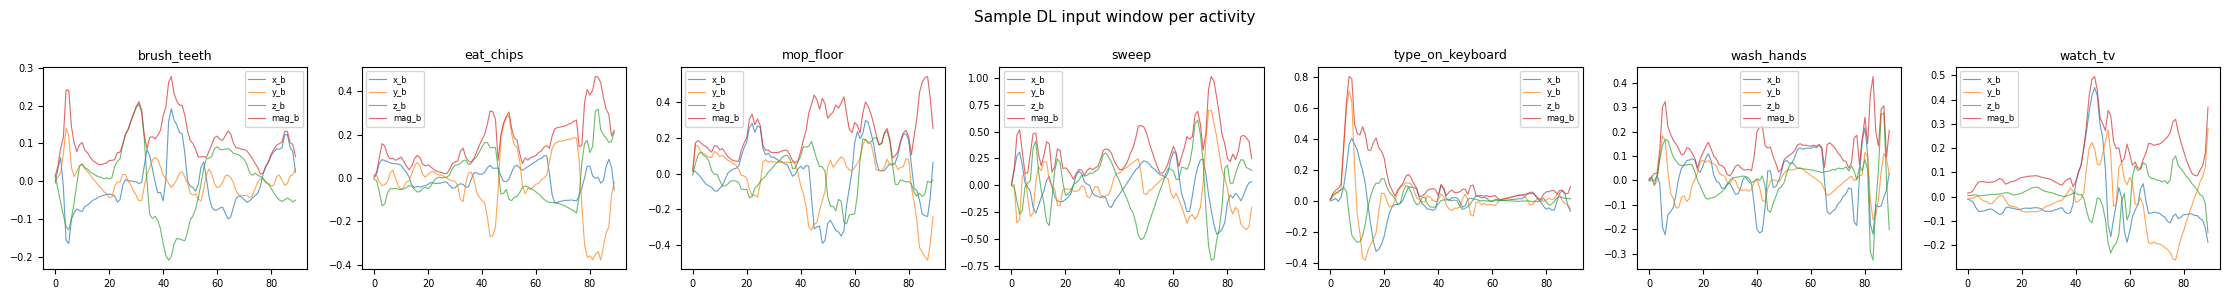

In [27]:
import numpy as np
import matplotlib.pyplot as plt


DL_WINDOW_SEC = 3.0
DL_OVERLAP = 0.5
DL_CHANNELS = ["x_b", "y_b", "z_b", "mag_b"]   # body-acceleration channels

windows = []
window_labels = []

for activity, df in raw_data.items():
    fs = estimate_sampling_rate(df)
    window_size = int(DL_WINDOW_SEC * fs)
    step_size = max(1, int(window_size * (1 - DL_OVERLAP)))
    n_samples = len(df)

    if n_samples < window_size:
        continue

    for start in range(0, n_samples - window_size + 1, step_size):
        chans = np.stack(
            [df[c].values[start:start + window_size] for c in DL_CHANNELS],
            axis=-1,
        )
        windows.append(chans)
        window_labels.append(activity)

X_dl = np.stack(windows)               # (n_windows, window_length, n_channels)
y_dl = np.array(window_labels)

print(f"Deep learning input X_dl shape:  {X_dl.shape}")
print(f"Deep learning labels y_dl shape: {y_dl.shape}")
print(f"Channels: {DL_CHANNELS}")
print(f"Unique activities: {sorted(set(y_dl))}")

# One sample window per activity (sanity check)
unique_acts = sorted(set(y_dl))
fig, axes = plt.subplots(1, len(unique_acts), figsize=(3.2 * len(unique_acts), 3))
for ax, act in zip(axes, unique_acts):
    idx = np.where(y_dl == act)[0][0]
    for ch_idx, ch_name in enumerate(DL_CHANNELS):
        ax.plot(X_dl[idx, :, ch_idx], alpha=0.7, linewidth=0.8, label=ch_name)
    ax.set_title(act, fontsize=9)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=6)
fig.suptitle("Sample DL input window per activity", fontsize=11)
plt.tight_layout()
plt.show()

For classical models, the data is preprocessed by encoding labels, applying a stratified train-test split, standardizing features, and evaluating multiple classifiers including Decision Tree, SVM, Naive Bayes, Random Forest, AdaBoost, and XGBoost. Performance is measured using accuracy, precision, recall, and macro F1-score. The results show that XGBoost performs best overall (80.36% accuracy, 0.798 F1), followed by Random Forest and SVM, while AdaBoost performs the worst. In addition, the raw sensor data is transformed into a deep learning format using a sliding window approach. Each sample represents 3 seconds of sensor readings (with 50% overlap) across multiple channels (x, y, z, and magnitude). This produces sequential input data X_dl with corresponding activity labels y_dl, suitable for models like LSTMs or CNNs. The dataset is verified by printing shapes and visualizing sample windows per activity to ensure correct segmentation.


__7. Advanced Modeling & Evaluation__

Standard Split Evaluation:
Accuracy: 0.7820
Precision: 0.7909
Recall: 0.7739
F1-score: 0.7760


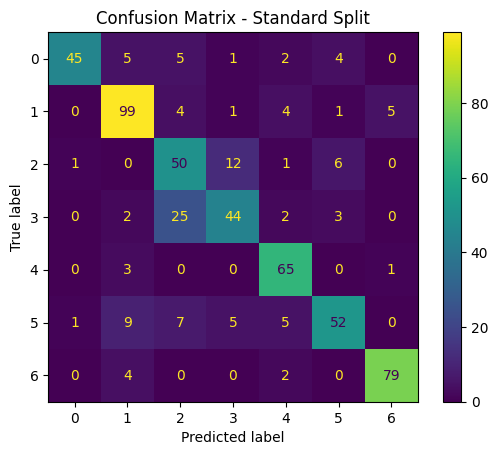

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest is safest
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
sw = compute_sample_weight(class_weight='balanced', y=y_train)
model.fit(X_train, y_train, sample_weight=sw)

y_pred = model.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print("Standard Split Evaluation:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Standard Split")
plt.show()

In [29]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
import pandas as pd

groups = feature_df["userid"]
gkf = GroupKFold(n_splits=groups.nunique())

cv_results = []

for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    test_user = groups.iloc[test_idx].iloc[0]

    model = XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        n_estimators=600,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.7,
        reg_lambda=5.0,
        gamma=1.0,
        min_child_weight=10,
        random_state=42,
        n_jobs=-1,
    )
    sw = compute_sample_weight(class_weight='balanced', y=y_train)
    model.fit(X_train, y_train, sample_weight=sw)
    y_pred = model.predict(X_test)

    cv_results.append({
        "fold": fold_idx,
        "test_user": test_user,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average='macro', zero_division=0),
        "recall": recall_score(y_test, y_pred, average='macro', zero_division=0),
        "f1": f1_score(y_test, y_pred, average='macro', zero_division=0),
    })

df_cv = pd.DataFrame(cv_results)

print("Per-fold leave-one-user-out results:")
display(df_cv)

print("\nMean across folds:")
print(df_cv[["accuracy", "precision", "recall", "f1"]].mean().round(4))

print("\nStd across folds:")
print(df_cv[["accuracy", "precision", "recall", "f1"]].std().round(4))

Per-fold leave-one-user-out results:


,fold,test_user,accuracy,precision,recall,f1
0,0,user1,0.632415,0.612565,0.655313,0.613652
1,1,user2,0.609023,0.628647,0.600200,0.594854
2,2,user3,0.631813,0.642136,0.628985,0.613628



Mean across folds:
accuracy     0.6244
precision    0.6278
recall       0.6282
f1           0.6074
dtype: float64

Std across folds:
accuracy     0.0133
precision    0.0148
recall       0.0276
f1           0.0108
dtype: float64


In [30]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, f1_score

WINDOW_SECS = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]

results = []

for w_sec in WINDOW_SECS:
    # Re-extract features at this window size using the Section-3 pipeline.
    fdf = build_feature_table(raw_data, window_sec=w_sec, overlap=0.5)
    fcols = [c for c in fdf.columns if c not in ("activity", "userid", "source")]

    le_local = LabelEncoder()
    fdf["activity_enc"] = le_local.fit_transform(fdf["activity"])

    Xw = fdf[fcols]
    yw = fdf["activity_enc"]
    gw = fdf["userid"]

    # --- Standard 80/20 stratified split ---
    Xtr, Xte, ytr, yte = train_test_split(Xw, yw, test_size=0.2, random_state=42, stratify=yw)
    sw_split = compute_sample_weight(class_weight='balanced', y=ytr)
    m_split = RandomForestClassifier(n_estimators=100, random_state=42)
    m_split.fit(Xtr, ytr, sample_weight=sw_split)
    yp_split = m_split.predict(Xte)
    split_acc = accuracy_score(yte, yp_split)
    split_f1 = f1_score(yte, yp_split, average='macro', zero_division=0)

    # --- Leave-one-subject-out CV ---
    gkf = GroupKFold(n_splits=gw.nunique())
    loso_accs, loso_f1s = [], []
    for tr_idx, te_idx in gkf.split(Xw, yw, groups=gw):
        Xtr_l, Xte_l = Xw.iloc[tr_idx], Xw.iloc[te_idx]
        ytr_l, yte_l = yw.iloc[tr_idx], yw.iloc[te_idx]
        sw_l = compute_sample_weight(class_weight='balanced', y=ytr_l)
        m_l = RandomForestClassifier(n_estimators=100, random_state=42)
        m_l.fit(Xtr_l, ytr_l, sample_weight=sw_l)
        yp_l = m_l.predict(Xte_l)
        loso_accs.append(accuracy_score(yte_l, yp_l))
        loso_f1s.append(f1_score(yte_l, yp_l, average='macro', zero_division=0))

    loso_acc_mean, loso_acc_std = float(np.mean(loso_accs)), float(np.std(loso_accs))
    loso_f1_mean, loso_f1_std = float(np.mean(loso_f1s)), float(np.std(loso_f1s))

    results.append({
        "window_sec":     w_sec,
        "n_windows":      len(Xw),
        "split_acc":      split_acc,
        "split_f1":       split_f1,
        "loso_acc_mean":  loso_acc_mean,
        "loso_acc_std":   loso_acc_std,
        "loso_f1_mean":   loso_f1_mean,
        "loso_f1_std":    loso_f1_std,
    })

    print(f"window={w_sec:.1f}s  n={len(Xw):>4}  | split_acc={split_acc:.3f} f1={split_f1:.3f} | "
          f"loso_acc={loso_acc_mean:.3f}±{loso_acc_std:.3f} f1={loso_f1_mean:.3f}")

df_windows = pd.DataFrame(results).round(4)

print("\n=== Window-size sweep results ===")
display(df_windows)

best_split_w = df_windows.loc[df_windows["split_acc"].idxmax(), "window_sec"]
best_loso_w = df_windows.loc[df_windows["loso_acc_mean"].idxmax(), "window_sec"]
print(f"\nBest window for standard split: {best_split_w}s")
print(f"Best window for LOSO:           {best_loso_w}s")

window=0.5s  n=17895  | split_acc=0.665 f1=0.658 | loso_acc=0.505±0.039 f1=0.493
window=1.0s  n=8345  | split_acc=0.721 f1=0.716 | loso_acc=0.549±0.034 f1=0.539
window=1.5s  n=5686  | split_acc=0.765 f1=0.760 | loso_acc=0.581±0.035 f1=0.565
window=2.0s  n=4167  | split_acc=0.783 f1=0.778 | loso_acc=0.613±0.033 f1=0.597
window=2.5s  n=3377  | split_acc=0.790 f1=0.791 | loso_acc=0.605±0.027 f1=0.592
window=3.0s  n=2774  | split_acc=0.805 f1=0.802 | loso_acc=0.609±0.032 f1=0.593
window=3.5s  n=2400  | split_acc=0.792 f1=0.785 | loso_acc=0.629±0.032 f1=0.615
window=4.0s  n=2078  | split_acc=0.784 f1=0.780 | loso_acc=0.631±0.035 f1=0.621
window=4.5s  n=1859  | split_acc=0.841 f1=0.842 | loso_acc=0.632±0.036 f1=0.618
window=5.0s  n=1661  | split_acc=0.835 f1=0.835 | loso_acc=0.643±0.028 f1=0.630

=== Window-size sweep results ===


,window_sec,n_windows,split_acc,split_f1,loso_acc_mean,loso_acc_std,loso_f1_mean,loso_f1_std
0,0.5,17895,0.6650,0.6578,0.5050,0.0392,0.4925,0.0344
1,1.0,8345,0.7214,0.7156,0.5493,0.0344,0.5387,0.0298
2,1.5,5686,0.7654,0.7604,0.5805,0.0353,0.5655,0.0319
3,2.0,4167,0.7830,0.7785,0.6132,0.0329,0.5973,0.0285
4,2.5,3377,0.7899,0.7910,0.6053,0.0267,0.5924,0.0229
5,3.0,2774,0.8054,0.8016,0.6087,0.0318,0.5928,0.0258
6,3.5,2400,0.7917,0.7852,0.6288,0.0325,0.6147,0.0285
7,4.0,2078,0.7837,0.7802,0.6312,0.0350,0.6209,0.0348
8,4.5,1859,0.8414,0.8415,0.6320,0.0359,0.6182,0.0325
9,5.0,1661,0.8348,0.8348,0.6430,0.0276,0.6297,0.0287



Best window for standard split: 4.5s
Best window for LOSO:           5.0s


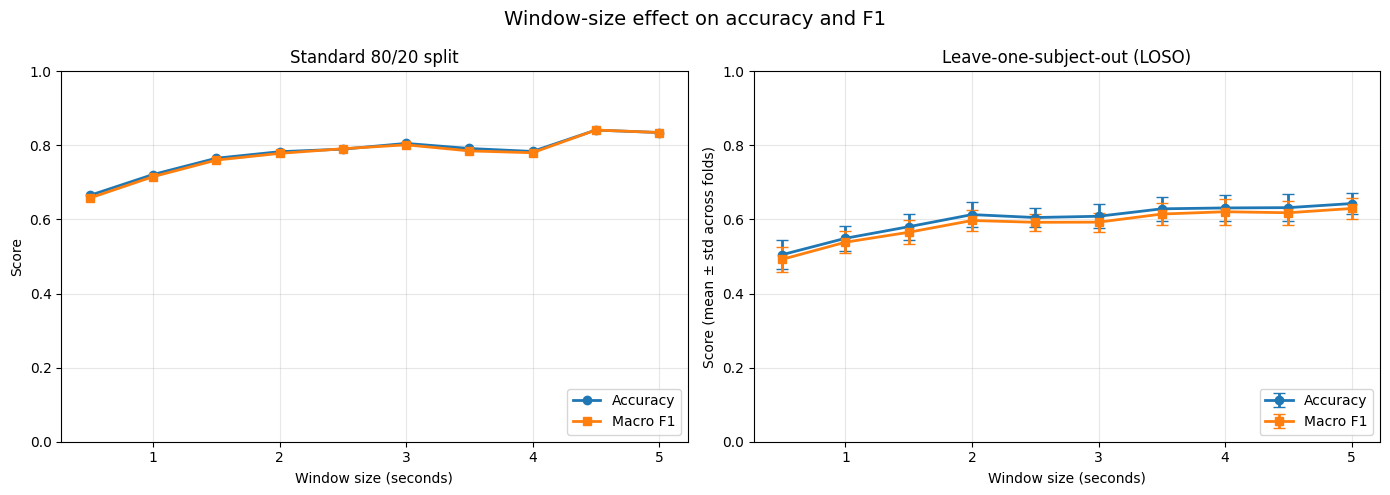

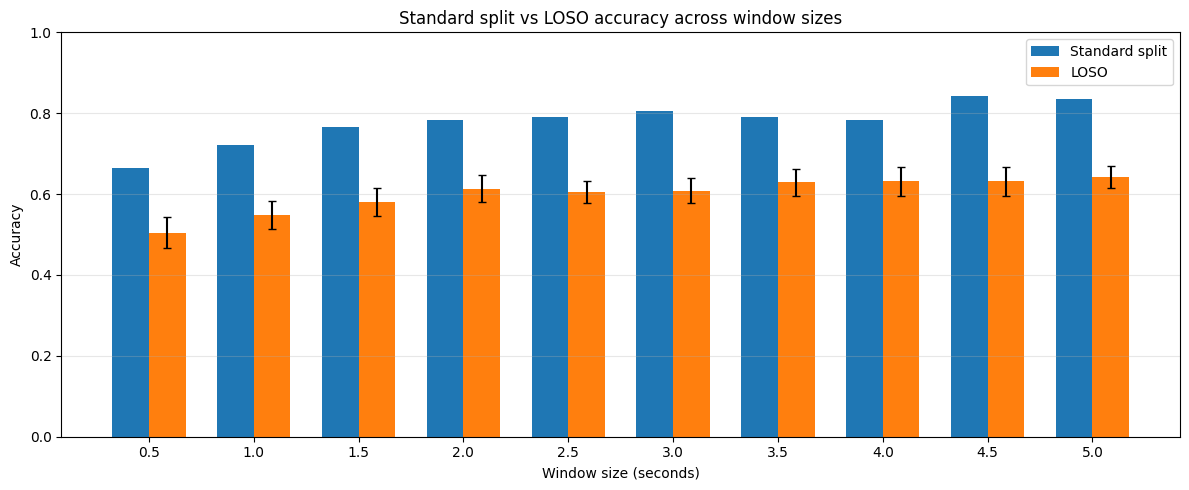

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Two side-by-side line plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(df_windows["window_sec"], df_windows["split_acc"], marker="o", linewidth=2, label="Accuracy")
ax.plot(df_windows["window_sec"], df_windows["split_f1"], marker="s", linewidth=2, label="Macro F1")
ax.set_xlabel("Window size (seconds)")
ax.set_ylabel("Score")
ax.set_title("Standard 80/20 split")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right")

ax = axes[1]
ax.errorbar(df_windows["window_sec"], df_windows["loso_acc_mean"],
            yerr=df_windows["loso_acc_std"], marker="o", linewidth=2, capsize=4, label="Accuracy")
ax.errorbar(df_windows["window_sec"], df_windows["loso_f1_mean"],
            yerr=df_windows["loso_f1_std"], marker="s", linewidth=2, capsize=4, label="Macro F1")
ax.set_xlabel("Window size (seconds)")
ax.set_ylabel("Score (mean ± std across folds)")
ax.set_title("Leave-one-subject-out (LOSO)")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right")

fig.suptitle("Window-size effect on accuracy and F1", fontsize=14)
plt.tight_layout()
plt.show()

# Bar chart for direct side-by-side accuracy comparison
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df_windows))
width = 0.35
ax.bar(x - width/2, df_windows["split_acc"], width, label="Standard split", color="#1f77b4")
ax.bar(x + width/2, df_windows["loso_acc_mean"], width, label="LOSO",
       color="#ff7f0e", yerr=df_windows["loso_acc_std"], capsize=3)
ax.set_xticks(x)
ax.set_xticklabels([f"{w:.1f}" for w in df_windows["window_sec"]])
ax.set_xlabel("Window size (seconds)")
ax.set_ylabel("Accuracy")
ax.set_title("Standard split vs LOSO accuracy across window sizes")
ax.set_ylim(0, 1)
ax.grid(True, axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [32]:
final_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (macro)", "Recall (macro)", "F1 (macro)"],
    "Standard 80/20 (XGBoost)": [
        results_df.loc["XGBoost", "Accuracy"],
        results_df.loc["XGBoost", "Precision"],
        results_df.loc["XGBoost", "Recall"],
        results_df.loc["XGBoost", "F1"],
    ],
    "LOSO mean (XGBoost)": [
        df_cv["accuracy"].mean(),
        df_cv["precision"].mean(),
        df_cv["recall"].mean(),
        df_cv["f1"].mean(),
    ],
    "LOSO std": [
        df_cv["accuracy"].std(),
        df_cv["precision"].std(),
        df_cv["recall"].std(),
        df_cv["f1"].std(),
    ],
}).round(4)

print("Final metrics — XGBoost: Standard 80/20 split vs Leave-One-Subject-Out CV")
print(final_metrics.to_string(index=False))

Final metrics — XGBoost: Standard 80/20 split vs Leave-One-Subject-Out CV
           Metric  Standard 80/20 (XGBoost)  LOSO mean (XGBoost)  LOSO std
         Accuracy                    0.8036               0.6244    0.0133
Precision (macro)                    0.8016               0.6278    0.0148
   Recall (macro)                    0.7973               0.6282    0.0276
       F1 (macro)                    0.7983               0.6074    0.0108


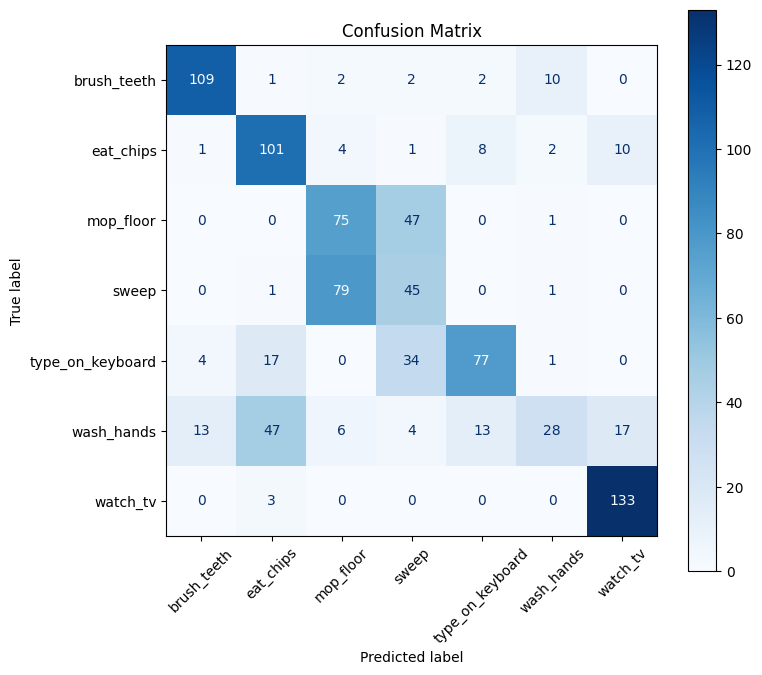

In [33]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Use activity names (decoded from LabelEncoder `le` from cell 26) as tick labels
# instead of integer-encoded class indices. Sort labels so axes are consistent.
labels_int = sorted(np.unique(np.concatenate([np.asarray(y_test), np.asarray(y_pred)])))
labels_str = [le.inverse_transform([int(l)])[0] for l in labels_int]

cm = confusion_matrix(y_test, y_pred, labels=labels_int)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_str)

fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=True)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [34]:
import numpy as np

y_true_arr = np.asarray(y_test)
y_pred_arr = np.asarray(y_pred)

def _name(lbl):
    return le.inverse_transform([int(lbl)])[0]

errors = y_true_arr != y_pred_arr
print("Total Errors:", int(errors.sum()))

error_indices = np.where(errors)[0][:10]

for i in error_indices:
    print(f"True: {_name(y_true_arr[i])}, Predicted: {_name(y_pred_arr[i])}")

Total Errors: 331
True: watch_tv, Predicted: eat_chips
True: watch_tv, Predicted: eat_chips
True: watch_tv, Predicted: eat_chips
True: eat_chips, Predicted: brush_teeth
True: eat_chips, Predicted: mop_floor
True: eat_chips, Predicted: mop_floor
True: eat_chips, Predicted: sweep
True: eat_chips, Predicted: wash_hands
True: eat_chips, Predicted: mop_floor
True: eat_chips, Predicted: wash_hands
